Saving Advertising.csv to Advertising (2).csv
Dataset Preview:
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

R2 Score: 0.8994
Predicted Sales: 20.61


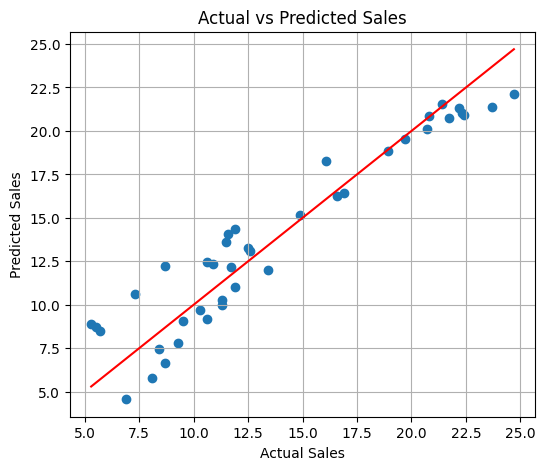

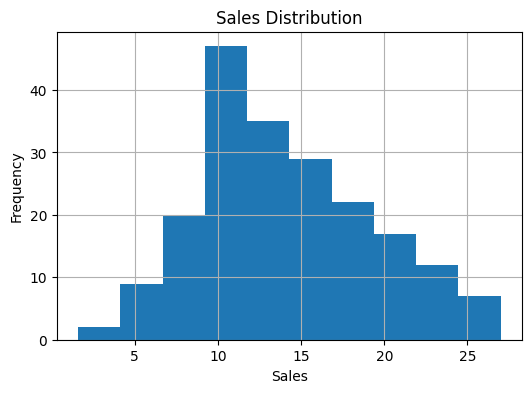

In [7]:
# CODSOFT - Task 4: Sales Prediction Using Python

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Upload Dataset
uploaded = files.upload()

# Read uploaded file automatically
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Display Dataset
print("Dataset Preview:")
print(df.head())

# Features and Target
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# R2 Score
score = r2_score(y_test, y_pred)
print("\nR2 Score:", round(score, 4))

# Sample Prediction
sample = pd.DataFrame(
    [[230.1, 37.8, 69.2]],
    columns=['TV', 'radio', 'newspaper']
)

prediction = model.predict(sample)
print("Predicted Sales:", round(prediction[0], 2))

# Actual vs Predicted Graph
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.show()

# Sales Distribution Graph
plt.figure(figsize=(6,4))
plt.hist(df['sales'], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()